##Mountain Car trying to go top a hill Q-learning

Episode 1/5000 - Total Reward: -200.0 - Epsilon: 0.995
Episode 100/5000 - Total Reward: -200.0 - Epsilon: 0.606
Episode 200/5000 - Total Reward: -200.0 - Epsilon: 0.367
Episode 300/5000 - Total Reward: -200.0 - Epsilon: 0.222
Episode 400/5000 - Total Reward: -200.0 - Epsilon: 0.135
Episode 500/5000 - Total Reward: -200.0 - Epsilon: 0.082
Episode 600/5000 - Total Reward: -200.0 - Epsilon: 0.049
Episode 700/5000 - Total Reward: -200.0 - Epsilon: 0.030
Episode 800/5000 - Total Reward: -200.0 - Epsilon: 0.018
Episode 900/5000 - Total Reward: -200.0 - Epsilon: 0.011
Episode 1000/5000 - Total Reward: -200.0 - Epsilon: 0.010
Episode 1100/5000 - Total Reward: -200.0 - Epsilon: 0.010
Episode 1200/5000 - Total Reward: -200.0 - Epsilon: 0.010
Episode 1300/5000 - Total Reward: -200.0 - Epsilon: 0.010
Episode 1400/5000 - Total Reward: -193.0 - Epsilon: 0.010
Episode 1500/5000 - Total Reward: -163.0 - Epsilon: 0.010
Episode 1600/5000 - Total Reward: -200.0 - Epsilon: 0.010
Episode 1700/5000 - Total 

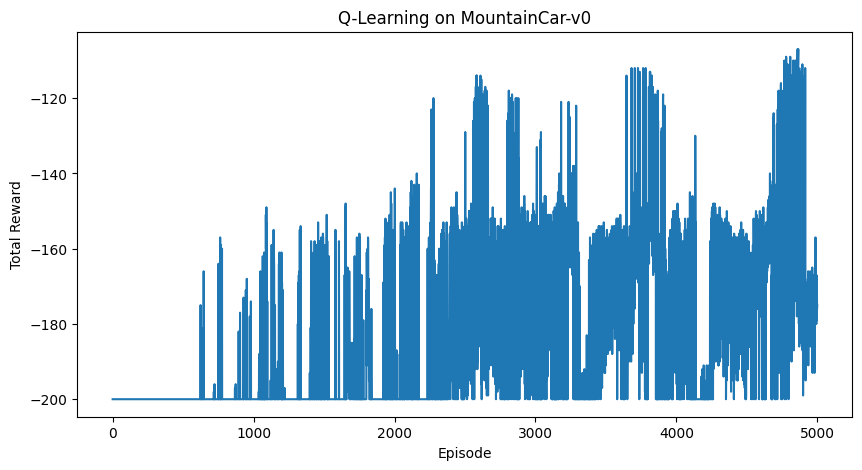

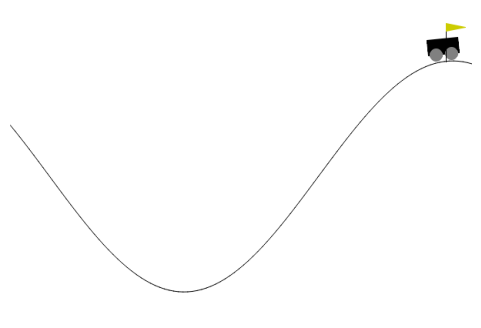

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Environment and Q-learning setup
env = gym.make("MountainCar-v0", render_mode="rgb_array")  # rgb_array for animation

# Q-learning parameters
n_states = (20, 20)
episodes = 5000
max_steps = 200
learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

# Discretize the continuous state space
def discretize_state(state, n_states):
    env_low = env.observation_space.low
    env_high = env.observation_space.high
    env_dx = (env_high - env_low) / n_states
    pos, vel = state
    return (int((pos - env_low[0]) / env_dx[0]), int((vel - env_low[1]) / env_dx[1]))

# Initialize Q-table
q_table = np.zeros(n_states + (env.action_space.n,))

# Training loop
rewards_list = []

for episode in range(1, episodes + 1):
    state, _ = env.reset()
    state_idx = discretize_state(state, n_states)
    total_reward = 0

    for step in range(max_steps):
        # Epsilon-greedy action
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state_idx])

        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state_idx = discretize_state(next_state, n_states)

        # Q-learning update
        best_next_action = np.argmax(q_table[next_state_idx])
        td_target = reward + discount_factor * q_table[next_state_idx + (best_next_action,)]
        q_table[state_idx + (action,)] += learning_rate * (td_target - q_table[state_idx + (action,)])

        state_idx = next_state_idx
        total_reward += reward

        if terminated or truncated:
            break

    rewards_list.append(total_reward)

    # Decay epsilon
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    # Verbose output
    if episode % 100 == 0 or episode == 1:
        print(f"Episode {episode}/{episodes} - Total Reward: {total_reward} - Epsilon: {epsilon:.3f}")

# Plot total rewards per episode
plt.figure(figsize=(10, 5))
plt.plot(rewards_list)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning on MountainCar-v0")
plt.show()

# Test trained agent and capture frames
state, info = env.reset()
state_idx = discretize_state(state, n_states)
done = False
frames = []

while not done:
    frame = env.render()  # capture frame
    frames.append(frame)
    action = np.argmax(q_table[state_idx])
    next_state, reward, terminated, truncated, info = env.step(action)
    state_idx = discretize_state(next_state, n_states)
    done = terminated or truncated
    state = next_state

env.close()

# Create inline animation
fig = plt.figure(figsize=(6, 4))
plt.axis("off")
im = plt.imshow(frames[0])

def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

# Display inline in Jupyter Notebook
HTML(ani.to_jshtml())


##Roulette Q-learning

Episode 1000/8000 | Avg Reward: -0.82
Episode 2000/8000 | Avg Reward: 14.83
Episode 3000/8000 | Avg Reward: 58.93
Episode 4000/8000 | Avg Reward: 99.93
Episode 5000/8000 | Avg Reward: 97.93
Episode 6000/8000 | Avg Reward: 119.47
Episode 7000/8000 | Avg Reward: 117.42
Episode 8000/8000 | Avg Reward: 101.59


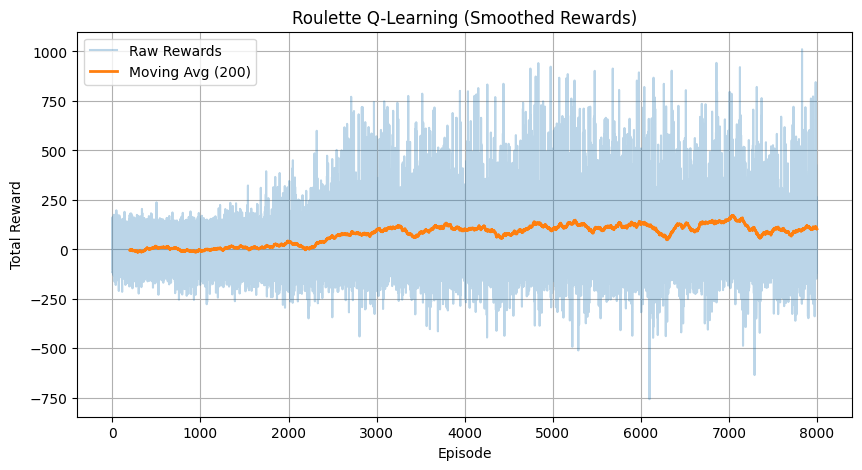

Test 1: Final Balance = 101, Total Reward = 222.10000000000002
Test 2: Final Balance = 112, Total Reward = 143.9
Test 3: Final Balance = -34, Total Reward = -123.80000000000003
Test 4: Final Balance = -9, Total Reward = -151.3
Test 5: Final Balance = 101, Total Reward = 556.9
Test 6: Final Balance = 112, Total Reward = 130.1
Test 7: Final Balance = 103, Total Reward = 379.2
Test 8: Final Balance = -14, Total Reward = -131.60000000000002
Test 9: Final Balance = 102, Total Reward = 323.3
Test 10: Final Balance = -4, Total Reward = -6.600000000000016

Goal Reached in 6/10 tests (60.0% success rate)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

class RouletteEnv:
    def __init__(self, start_balance=50, target_balance=100, max_steps=300):
        self.start_balance = start_balance
        self.target_balance = target_balance
        self.max_steps = max_steps
        self.bet_sizes = [1, 5, 10]
        self.colors = ["red", "black"]  # safer 50/50 bets
        self.action_space = len(self.colors) * len(self.bet_sizes)
        self.reset()

    def reset(self):
        self.balance = self.start_balance
        self.steps = 0
        return self._discretize_balance(self.balance)

    def _discretize_balance(self, balance):
        return min(balance // 2, 150)

    def step(self, action):
        color_choice = self.colors[action % 2]
        bet_size = self.bet_sizes[action // 2]

        reward = 0
        for _ in range(5):  # average spins
            spin = np.random.randint(0, 37)
            spin_color = "red" if spin in [1,3,5,7,9,12,14,16,18,19,21,23,25,27,30,32,34,36] else "black"
            if spin_color == color_choice:
                reward += bet_size
            else:
                reward -= bet_size

        self.balance += reward
        self.steps += 1
        done = self.balance <= 0 or self.balance >= self.target_balance or self.steps >= self.max_steps

        # Shaped reward
        shaped_reward = reward + 0.1 * (self.balance - self.start_balance)
        if self.balance >= self.target_balance:
            shaped_reward += 50
        elif self.balance <= 0:
            shaped_reward -= 50

        next_state = self._discretize_balance(self.balance)
        return next_state, shaped_reward, done


def q_learning(
    episodes=8000,
    alpha=0.1,
    gamma=0.95,
    epsilon=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.999
):
    env = RouletteEnv()
    state_space = 151
    action_space = env.action_space
    Q = np.zeros((state_space, action_space))
    rewards_per_episode = []

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0

        for _ in range(env.max_steps):
            if random.random() < epsilon:
                action = random.randint(0, action_space - 1)
            else:
                action = np.argmax(Q[state])

            next_state, reward, done = env.step(action)
            total_reward += reward

            Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])
            state = next_state

            if done:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_per_episode.append(total_reward)

        if (ep + 1) % 1000 == 0:
            avg_reward = np.mean(rewards_per_episode[-1000:])
            print(f"Episode {ep+1}/{episodes} | Avg Reward: {avg_reward:.2f}")

    return Q, rewards_per_episode, env


Q, rewards, env = q_learning()


def plot_with_moving_average(rewards, window=200):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, alpha=0.3, label="Raw Rewards")
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(range(window - 1, len(rewards)), moving_avg, label=f"Moving Avg ({window})", linewidth=2)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("Roulette Q-Learning (Smoothed Rewards)")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_with_moving_average(rewards)


def test_agent(Q, env, runs=10):
    success_count = 0
    for r in range(runs):
        state = env.reset()
        total_reward = 0
        for _ in range(env.max_steps):
            action = np.argmax(Q[state])
            next_state, reward, done = env.step(action)
            total_reward += reward
            state = next_state
            if done:
                if env.balance >= env.target_balance:
                    success_count += 1
                break
        print(f"Test {r+1}: Final Balance = {env.balance}, Total Reward = {total_reward}")

    print(f"\nGoal Reached in {success_count}/{runs} tests "
          f"({(success_count / runs) * 100:.1f}% success rate)")


test_agent(Q, env)


##Mountain Car trying to go top a hill DRL using DQN


Ep 1/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.963
Ep 2/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.927
Ep 3/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.893
Ep 4/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.860
Ep 5/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.828
Ep 6/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.797
Ep 7/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.768
Ep 8/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.740
Ep 9/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.713
Ep 10/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.687
Ep 11/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.662
Ep 12/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.638
Ep 13/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.615
Ep 14/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.593
Ep 15/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.571
Ep 16/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.551
Ep 17/500 | Reward: -200.0 | Avg(20): -200.0 | Eps: 0.531
Ep 18/500 | Reward: -20

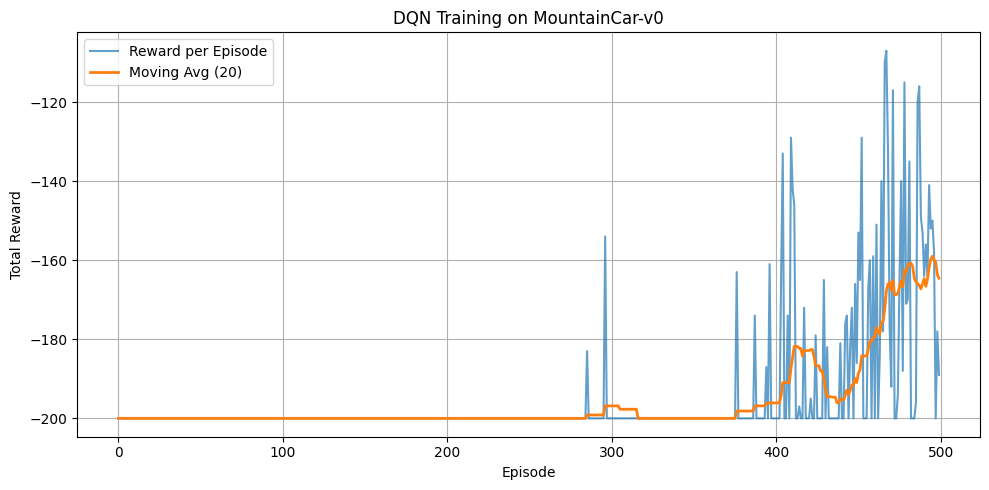

 Training complete, model saved to dqn_mountaincar.pth


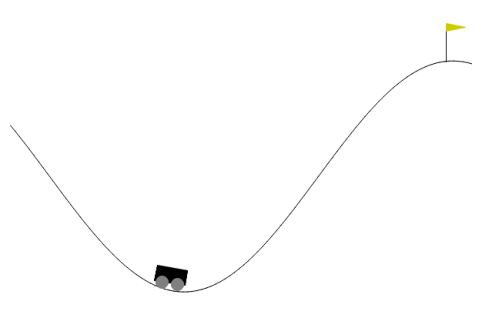

In [ ]:
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.animation as animation


# Hyperparameters

ENV_NAME = "MountainCar-v0"
EPISODES = 500
GAMMA = 0.99
LR = 1e-3
BATCH_SIZE = 64
BUFFER_SIZE = 100_000
TARGET_UPDATE = 1000
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 5000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Q-Network

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)


# Replay Buffer

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        return (
            torch.FloatTensor(states).to(DEVICE),
            torch.LongTensor(actions).unsqueeze(1).to(DEVICE),
            torch.FloatTensor(rewards).unsqueeze(1).to(DEVICE),
            torch.FloatTensor(next_states).to(DEVICE),
            torch.FloatTensor(dones).unsqueeze(1).to(DEVICE)
        )

    def __len__(self):
        return len(self.buffer)


# Epsilon Schedule

def epsilon_by_step(step):
    return EPS_END + (EPS_START - EPS_END) * np.exp(-1.0 * step / EPS_DECAY)


# Initialize

env = gym.make(ENV_NAME)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy_net = QNetwork(state_dim, action_dim).to(DEVICE)
target_net = QNetwork(state_dim, action_dim).to(DEVICE)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
replay_buffer = ReplayBuffer(BUFFER_SIZE)

rewards_history = []
avg_rewards = []
global_step = 0


# Training Loop

for episode in range(EPISODES):
    state, info = env.reset()
    total_reward = 0
    done = False

    while not done:
        epsilon = epsilon_by_step(global_step)
        global_step += 1

        # Epsilon-greedy
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
                q_values = policy_net(state_tensor)
                action = q_values.argmax().item()

        # Step
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        # Train
        if len(replay_buffer) > BATCH_SIZE:
            states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)

            q_values = policy_net(states).gather(1, actions)
            with torch.no_grad():
                next_q_values = target_net(next_states).max(1, keepdim=True)[0]
                target_q = rewards + (1 - dones) * GAMMA * next_q_values

            loss = nn.functional.mse_loss(q_values, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if global_step % TARGET_UPDATE == 0:
            target_net.load_state_dict(policy_net.state_dict())

    rewards_history.append(total_reward)
    avg_reward = np.mean(rewards_history[-20:])
    avg_rewards.append(avg_reward)
    print(f"Ep {episode+1}/{EPISODES} | Reward: {total_reward:.1f} | Avg(20): {avg_reward:.1f} | Eps: {epsilon:.3f}")

env.close()


# Plot Training Rewards

plt.figure(figsize=(10, 5))
plt.plot(rewards_history, label="Reward per Episode", alpha=0.7)
plt.plot(avg_rewards, label="Moving Avg (20)", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Training on MountainCar-v0")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Save Model

torch.save(policy_net.state_dict(), "dqn_mountaincar.pth")
print(" Training complete, model saved to dqn_mountaincar.pth")


# Visualization / Animation

env = gym.make(ENV_NAME, render_mode="rgb_array")
frames = []
state, info = env.reset()
done = False

while not done:
    frame = env.render()
    frames.append(frame)
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        action = policy_net(state_tensor).argmax().item()
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    state = next_state
env.close()

# Convert frames to animation
fig = plt.figure(figsize=(6, 4))
plt.axis("off")
im = plt.imshow(frames[0])

def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=frames, interval=30, blit=True)
plt.show()


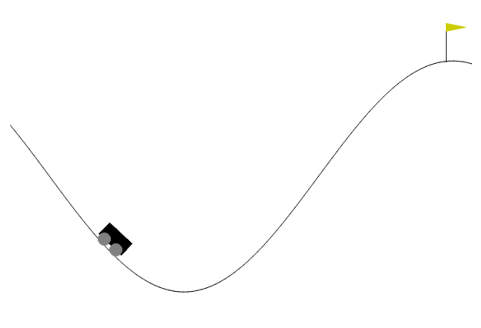

In [ ]:
from IPython.display import HTML
HTML(ani.to_html5_video())

# Visualization / Animation (Inline)

env = gym.make(ENV_NAME, render_mode="rgb_array")
frames = []
state, info = env.reset()
done = False

while not done:
    frame = env.render()
    frames.append(frame)
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        action = policy_net(state_tensor).argmax().item()
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    state = next_state
env.close()

# Create animation with matplotlib
fig = plt.figure(figsize=(6, 4))
plt.axis("off")
im = plt.imshow(frames[0])

def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=frames, interval=30, blit=True)

# Display inline in notebook
HTML(ani.to_jshtml())


##Roulette DRL using DQN


/tmp/ipython-input-1916349265.py:98: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(states).to(self.device)


Episode 500/5000 | Avg Reward: -29.61 | Epsilon: 0.050
Episode 1000/5000 | Avg Reward: -24.26 | Epsilon: 0.050
Episode 1500/5000 | Avg Reward: -8.52 | Epsilon: 0.050
Episode 2000/5000 | Avg Reward: -3.03 | Epsilon: 0.050
Episode 2500/5000 | Avg Reward: -9.16 | Epsilon: 0.050
Episode 3000/5000 | Avg Reward: -20.06 | Epsilon: 0.050
Episode 3500/5000 | Avg Reward: -60.82 | Epsilon: 0.050
Episode 4000/5000 | Avg Reward: -21.12 | Epsilon: 0.050
Episode 4500/5000 | Avg Reward: -39.94 | Epsilon: 0.050
Episode 5000/5000 | Avg Reward: -59.10 | Epsilon: 0.050


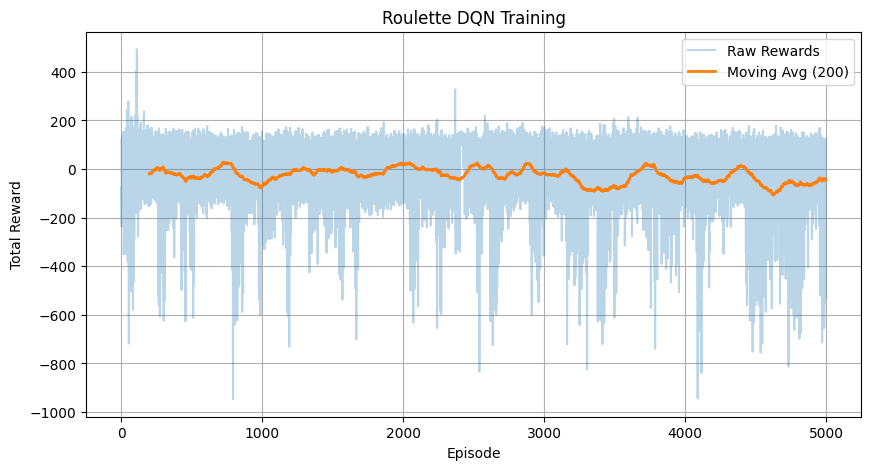

Test 1: Final Balance = -1, Total Reward = -145.6
Test 2: Final Balance = 101, Total Reward = 43.599999999999994
Test 3: Final Balance = 109, Total Reward = 51.30000000000002
Test 4: Final Balance = 109, Total Reward = 129.29999999999998
Test 5: Final Balance = 133, Total Reward = 59.69999999999999
Test 6: Final Balance = 100, Total Reward = 126.0
Test 7: Final Balance = 100, Total Reward = 105.0
Test 8: Final Balance = 100, Total Reward = 118.0
Test 9: Final Balance = 101, Total Reward = 18.09999999999995
Test 10: Final Balance = 100, Total Reward = 107.2

Goal Reached in 9/10 tests (90.0% success rate)


In [ ]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt

# Environment
class RouletteEnv:
    def __init__(self, start_balance=50, target_balance=100, max_steps=300):
        self.start_balance = start_balance
        self.target_balance = target_balance
        self.max_steps = max_steps
        self.bet_sizes = [1, 5, 10]
        self.colors = ["red", "black"]
        self.action_space = len(self.colors) * len(self.bet_sizes)
        self.reset()

    def reset(self):
        self.balance = self.start_balance
        self.steps = 0
        return np.array([self.balance], dtype=np.float32)

    def step(self, action):
        color_choice = self.colors[action % 2]
        bet_size = self.bet_sizes[action // 2]

        reward = 0
        for _ in range(5):
            spin = np.random.randint(0, 37)
            spin_color = "red" if spin in [1,3,5,7,9,12,14,16,18,19,21,23,25,27,30,32,34,36] else "black"
            if spin_color == color_choice:
                reward += bet_size
            else:
                reward -= bet_size

        self.balance += reward
        self.steps += 1
        done = self.balance <= 0 or self.balance >= self.target_balance or self.steps >= self.max_steps

        shaped_reward = reward + 0.1 * (self.balance - self.start_balance)
        if self.balance >= self.target_balance:
            shaped_reward += 50
        elif self.balance <= 0:
            shaped_reward -= 50

        return np.array([self.balance], dtype=np.float32), shaped_reward, done

# DQN Network
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.out = nn.Linear(64, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)

# DQN Agent
class DQNAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.95, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.memory = deque(maxlen=5000)
        self.batch_size = 64

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = DQN(state_dim, action_dim).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        state = torch.FloatTensor(state).to(self.device)
        q_values = self.model(state)
        return torch.argmax(q_values).item()

    def replay(self):
        if len(self.memory) < self.batch_size:
            return

        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        q_values = self.model(states).gather(1, actions)
        next_q = self.model(next_states).max(1)[0].unsqueeze(1)
        target = rewards + self.gamma * next_q * (1 - dones)

        loss = self.loss_fn(q_values, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Decay epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# Training
env = RouletteEnv()
state_dim = 1
action_dim = env.action_space
agent = DQNAgent(state_dim, action_dim)

episodes = 5000
rewards_per_episode = []

for ep in range(episodes):
    state = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = agent.act(state)
        next_state, reward, done = env.step(action)
        agent.remember(state, action, reward, next_state, done)
        agent.replay()
        state = next_state
        total_reward += reward

    rewards_per_episode.append(total_reward)
    if (ep+1) % 500 == 0:
        avg_reward = np.mean(rewards_per_episode[-500:])
        print(f"Episode {ep+1}/{episodes} | Avg Reward: {avg_reward:.2f} | Epsilon: {agent.epsilon:.3f}")

# Plotting
def plot_with_moving_average(rewards, window=200):
    plt.figure(figsize=(10,5))
    plt.plot(rewards, alpha=0.3, label="Raw Rewards")
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(rewards)), moving_avg, label=f"Moving Avg ({window})", linewidth=2)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("Roulette DQN Training")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_with_moving_average(rewards_per_episode)

# Test Agent
def test_agent(agent, env, runs=10):
    success_count = 0
    for r in range(runs):
        state = env.reset()
        total_reward = 0
        done = False
        while not done:
            action = agent.act(state)
            state, reward, done = env.step(action)
            total_reward += reward
        print(f"Test {r+1}: Final Balance = {env.balance}, Total Reward = {total_reward}")
        if env.balance >= env.target_balance:
            success_count += 1

    print(f"\nGoal Reached in {success_count}/{runs} tests ({(success_count/runs)*100:.1f}% success rate)")

test_agent(agent, env)


Episode 1/5000 - Total Reward: 22.0 - Epsilon: 0.999
Episode 500/5000 - Total Reward: -50.0 - Epsilon: 0.606
Episode 1000/5000 - Total Reward: 56.0 - Epsilon: 0.368
Episode 1500/5000 - Total Reward: -50.0 - Epsilon: 0.223
Episode 2000/5000 - Total Reward: -14.0 - Epsilon: 0.135
Episode 2500/5000 - Total Reward: 64.0 - Epsilon: 0.082
Episode 3000/5000 - Total Reward: 22.0 - Epsilon: 0.050
Episode 3500/5000 - Total Reward: 58.0 - Epsilon: 0.050
Episode 4000/5000 - Total Reward: -14.0 - Epsilon: 0.050
Episode 4500/5000 - Total Reward: -14.0 - Epsilon: 0.050
Episode 5000/5000 - Total Reward: 22.0 - Epsilon: 0.050


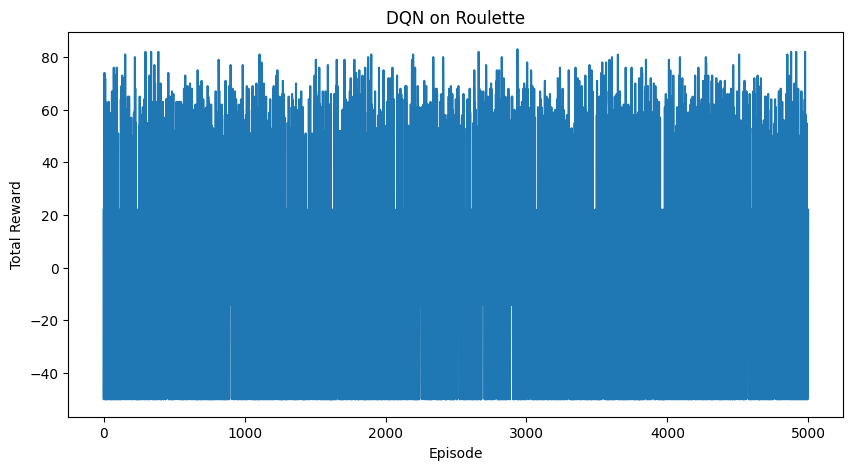

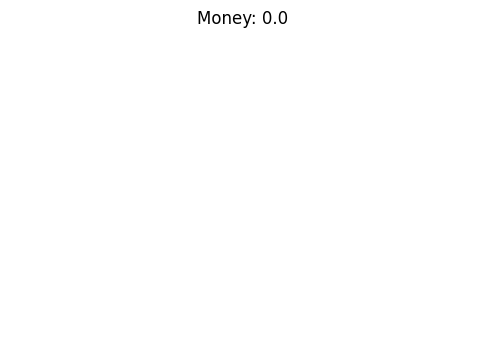

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
from matplotlib import animation
from IPython.display import HTML

# Simple Roulette Environment
class RouletteEnv:
    def __init__(self, max_money=100):
        self.max_money = max_money
        self.reset()

    def reset(self):
        self.money = 50
        self.done = False
        return np.array([self.money], dtype=np.float32)

    def step(self, action):
        if self.done:
            raise Exception("Episode is done. Reset environment.")

        winning_number = np.random.randint(0, 37)
        if action == winning_number:
            reward = 35
        else:
            reward = -1

        self.money += reward
        self.money = max(0, min(self.money, self.max_money))
        self.done = (self.money == 0 or self.money == self.max_money)

        return np.array([self.money], dtype=np.float32), reward, self.done, {}

# DQN Network
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.fc(x)

# Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.array, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)


# Hyperparameters

env = RouletteEnv(max_money=100)
state_dim = 1
action_dim = 37

episodes = 5000
max_steps = 50  # limit steps per episode
batch_size = 64
gamma = 0.95
lr = 1e-3
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.999

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Initialize

policy_net = DQN(state_dim, action_dim).to(device)
target_net = DQN(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=lr)
replay_buffer = ReplayBuffer(10000)
loss_fn = nn.MSELoss()


# Training Loop

rewards_list = []

for episode in range(1, episodes + 1):
    state = env.reset()
    total_reward = 0

    for step in range(max_steps):
        # Epsilon-greedy
        if np.random.random() < epsilon:
            action = np.random.randint(action_dim)
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                action = policy_net(state_tensor).argmax().item()

        next_state, reward, done, _ = env.step(action)
        replay_buffer.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        # Update network
        if len(replay_buffer) >= batch_size:
            s, a, r, s_next, d = replay_buffer.sample(batch_size)
            s = torch.FloatTensor(s).to(device)
            a = torch.LongTensor(a).unsqueeze(1).to(device)
            r = torch.FloatTensor(r).unsqueeze(1).to(device)
            s_next = torch.FloatTensor(s_next).to(device)
            d = torch.FloatTensor(d).unsqueeze(1).to(device)

            q_values = policy_net(s).gather(1, a)
            with torch.no_grad():
                q_next = target_net(s_next).max(1)[0].unsqueeze(1)
                q_target = r + gamma * q_next * (1 - d)
            loss = loss_fn(q_values, q_target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break

    rewards_list.append(total_reward)

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Update target network
    if episode % 100 == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Verbose
    if episode % 500 == 0 or episode == 1:
        print(f"Episode {episode}/{episodes} - Total Reward: {total_reward:.1f} - Epsilon: {epsilon:.3f}")


# Plot total rewards

plt.figure(figsize=(10,5))
plt.plot(rewards_list)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN on Roulette")
plt.show()


# Test trained agent and animate

state = env.reset()
done = False
money_history = [state[0]]

while not done:
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        action = policy_net(state_tensor).argmax().item()
    state, reward, done, _ = env.step(action)
    money_history.append(state[0])

# Animation
fig = plt.figure(figsize=(6,4))
plt.axis("off")
im = plt.bar([0], [money_history[0]], width=0.5, color='green')
plt.ylim(0, env.max_money)

def update(i):
    plt.cla()
    plt.bar([0], [money_history[i]], width=0.5, color='green')
    plt.ylim(0, env.max_money)
    plt.title(f"Money: {money_history[i]}")
    plt.axis('off')
    return []

ani = animation.FuncAnimation(fig, update, frames=len(money_history), interval=200, blit=True)
HTML(ani.to_jshtml())


Episode 1/5000 - Total Reward: -50 - Epsilon: 0.999
Episode 500/5000 - Total Reward: -14 - Epsilon: 0.606
Episode 1000/5000 - Total Reward: 22 - Epsilon: 0.368
Episode 1500/5000 - Total Reward: -14 - Epsilon: 0.223
Episode 2000/5000 - Total Reward: -14 - Epsilon: 0.135
Episode 2500/5000 - Total Reward: -50 - Epsilon: 0.082
Episode 3000/5000 - Total Reward: -50 - Epsilon: 0.050
Episode 3500/5000 - Total Reward: 60 - Epsilon: 0.050
Episode 4000/5000 - Total Reward: 22 - Epsilon: 0.050
Episode 4500/5000 - Total Reward: -50 - Epsilon: 0.050
Episode 5000/5000 - Total Reward: -14 - Epsilon: 0.050


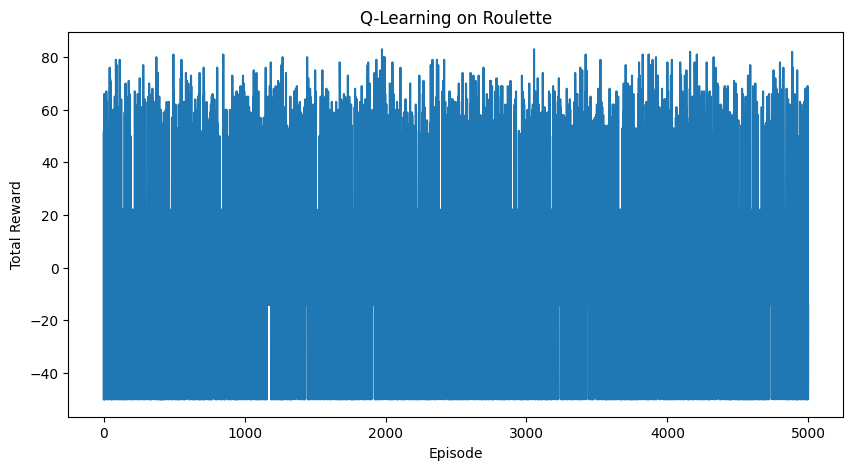

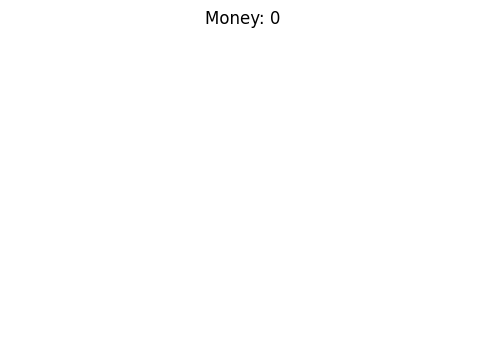

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML


# Roulette Environment

class RouletteEnv:
    def __init__(self, max_money=100):
        self.max_money = max_money
        self.reset()

    def reset(self):
        self.money = 50  # starting money
        self.done = False
        return self.money

    def step(self, action):
        """
        action: bet on a number 0-36
        """
        if self.done:
            raise Exception("Episode done. Reset environment.")

        winning_number = np.random.randint(0, 37)
        if action == winning_number:
            reward = 35
        else:
            reward = -1

        self.money += reward
        self.money = max(0, min(self.money, self.max_money))
        self.done = (self.money == 0 or self.money == self.max_money)

        return self.money, reward, self.done


# Q-learning setup

env = RouletteEnv(max_money=100)

n_states = env.max_money + 1  # each money value is a state: 0..100
n_actions = 37  # bet numbers 0-36

q_table = np.zeros((n_states, n_actions))

# Hyperparameters
episodes = 5000
max_steps = 50
learning_rate = 0.1
discount_factor = 0.95
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.999

rewards_list = []


# Training Loop

for episode in range(1, episodes + 1):
    state = env.reset()
    total_reward = 0

    for step in range(max_steps):
        # Epsilon-greedy
        if np.random.random() < epsilon:
            action = np.random.randint(n_actions)
        else:
            action = np.argmax(q_table[state])

        next_state, reward, done = env.step(action)

        # Q-learning update
        best_next_action = np.argmax(q_table[next_state])
        td_target = reward + discount_factor * q_table[next_state, best_next_action]
        q_table[state, action] += learning_rate * (td_target - q_table[state, action])

        state = next_state
        total_reward += reward

        if done:
            break

    rewards_list.append(total_reward)

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Verbose
    if episode % 500 == 0 or episode == 1:
        print(f"Episode {episode}/{episodes} - Total Reward: {total_reward} - Epsilon: {epsilon:.3f}")


# Plot rewards

plt.figure(figsize=(10,5))
plt.plot(rewards_list)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning on Roulette")
plt.show()


# Test trained agent and animate money

state = env.reset()
done = False
money_history = [state]

while not done:
    action = np.argmax(q_table[state])
    state, reward, done = env.step(action)
    money_history.append(state)

# Animation
fig = plt.figure(figsize=(6,4))
plt.axis("off")
im = plt.bar([0], [money_history[0]], width=0.5, color='green')
plt.ylim(0, env.max_money)

def update(i):
    plt.cla()
    plt.bar([0], [money_history[i]], width=0.5, color='green')
    plt.ylim(0, env.max_money)
    plt.title(f"Money: {money_history[i]}")
    plt.axis('off')
    return []

ani = animation.FuncAnimation(fig, update, frames=len(money_history), interval=200, blit=True)
HTML(ani.to_jshtml())


## RL and DRL for finding the shortest path in any user-input graph


In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class GraphShortestPathEnv(gym.Env):
    """
    Custom Gym environment for finding shortest path in a graph.
    States = nodes, Actions = edges, Rewards = -1 per step, +10 for goal.
    """
    def __init__(self, adjacency_dict, start_node, goal_node):
        super(GraphShortestPathEnv, self).__init__()
        self.graph = adjacency_dict
        self.nodes = list(adjacency_dict.keys())
        self.node_to_idx = {node: i for i, node in enumerate(self.nodes)}
        self.start_node = start_node
        self.goal_node = goal_node

        self.action_space = spaces.Discrete(len(self.nodes))
        self.observation_space = spaces.Discrete(len(self.nodes))
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_node = self.start_node
        return self.node_to_idx[self.current_node], {}

    def step(self, action):
        next_node = self.nodes[action]

        if next_node in self.graph[self.current_node]:
            self.current_node = next_node
            reward = 10 if next_node == self.goal_node else -1
        else:
            reward = -5

        done = self.current_node == self.goal_node
        return self.node_to_idx[self.current_node], reward, done, False, {}

    def render(self):
        print(f"Current node: {self.current_node}")


In [ ]:
graph = {
    'A': ['B', 'C'],
    'B': ['D'],
    'C': ['D', 'E'],
    'D': ['F'],
    'E': ['F'],
    'F': []
}
start_node = 'A'
goal_node = 'F'
env = GraphShortestPathEnv(graph, start_node, goal_node)


### Classical Reinforcement Learning (Tabular Q-Learning)


In [ ]:
import random

num_states = env.observation_space.n
num_actions = env.action_space.n
Q_table = np.zeros((num_states, num_actions))

alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
episodes = 300

rewards_tabular = []

for ep in range(episodes):
    state, _ = env.reset()
    total_reward = 0

    for _ in range(50):
        if random.random() < epsilon:
            action = random.randint(0, num_actions - 1)
        else:
            action = np.argmax(Q_table[state])

        next_state, reward, done, _, _ = env.step(action)
        best_next = np.max(Q_table[next_state])
        Q_table[state, action] += alpha * (reward + gamma * best_next - Q_table[state, action])

        state = next_state
        total_reward += reward
        if done:
            break

    epsilon *= epsilon_decay
    rewards_tabular.append(total_reward)


### Deep Reinforcement Learning (DQN)

In [ ]:
state_dim = 1
action_dim = env.action_space.n
import torch
import torch.nn as nn
import torch.optim as optim

EPISODES = 500
MAX_STEPS = 200
BATCH_SIZE = 64
LEARNING_RATE = 0.001
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995
UPDATE_TARGET_EVERY = 10
from collections import deque
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class DQNAgent:
    def __init__(self, input_dim, output_dim):
        self.policy_net = QNetwork(input_dim, output_dim).to(device)
        self.target_net = QNetwork(input_dim, output_dim).to(device)
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LEARNING_RATE)
        self.memory = deque(maxlen=10000)
        self.epsilon = EPSILON_START
        self.steps_done = 0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return env.action_space.sample()
        else:
            with torch.no_grad():
                state = np.array(state)
                state = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = self.policy_net(state)
                return torch.argmax(q_values).item()

    def store_experience(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def sample_experience(self):
        return random.sample(self.memory, BATCH_SIZE)

    def update(self):
        if len(self.memory) < BATCH_SIZE:
            return
        experiences = self.sample_experience()
        states, actions, rewards, next_states, dones = zip(*experiences)

        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

        q_values = self.policy_net(states).gather(1, actions)
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (1 - dones) * GAMMA * next_q_values

        loss = nn.MSELoss()(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

agent = DQNAgent(input_dim=state_dim, output_dim=action_dim)

rewards_drl = []

for ep in range(episodes):
    state, _ = env.reset()
    total_reward = 0

    for _ in range(50):
        state_tensor = np.array([state], dtype=np.float32)
        action = agent.select_action(state_tensor)
        next_state, reward, done, _, _ = env.step(action)

        next_state_tensor = np.array([next_state], dtype=np.float32)
        agent.store_experience(state_tensor, action, reward, next_state_tensor, done)
        agent.update()

        state = next_state
        total_reward += reward
        if done:
            break

    agent.epsilon = max(EPSILON_END, agent.epsilon * EPSILON_DECAY)
    if ep % UPDATE_TARGET_EVERY == 0:
        agent.update_target_network()

    rewards_drl.append(total_reward)


### Performance Comparison



In [ ]:
import pandas as pd

comparison_table = pd.DataFrame({
    'Metric': ['Average Reward', 'Convergence Episodes', 'Optimal Path Found (%)'],
    'RL (Q-learning)': [
        np.mean(rewards_tabular[-50:]),
        np.argmax(rewards_tabular),
        (sum(r > 0 for r in rewards_tabular[-50:]) / 50) * 100
    ],
    'DRL (DQN)': [
        np.mean(rewards_drl[-50:]),
        np.argmax(rewards_drl),
        (sum(r > 0 for r in rewards_drl[-50:]) / 50) * 100
    ]
})

print("\nPerformance Comparison (RL vs DRL):\n")
print(comparison_table)



Performance Comparison (RL vs DRL):

                   Metric  RL (Q-learning)  DRL (DQN)
0          Average Reward              5.1        5.0
1    Convergence Episodes             24.0       56.0
2  Optimal Path Found (%)             86.0       88.0


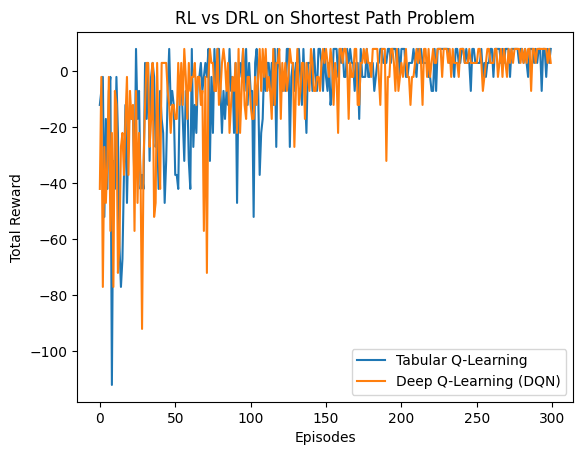

In [ ]:

import matplotlib.pyplot as plt
plt.plot(rewards_tabular, label='Tabular Q-Learning')
plt.plot(rewards_drl, label='Deep Q-Learning (DQN)')
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('RL vs DRL on Shortest Path Problem')
plt.legend()
plt.show()
